In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
from google.colab import files

uploaded = files.upload()

Saving traffic.csv to traffic.csv


In [3]:
df = pd.read_csv("traffic.csv", encoding='latin1')

df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores MÃ¡s,No Llores MÃ¡s,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,MalÃ©,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [4]:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (226278, 9)

Data types:
event      object
date       object
country    object
city       object
artist     object
album      object
track      object
isrc       object
linkid     object
dtype: object

Missing values:
event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64


In [5]:
# Data cleaning

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Fill missing values
df["country"] = df["country"].fillna("Unknown")
df["city"] = df["city"].fillna("Unknown")
df["artist"] = df["artist"].fillna("Unknown")
df["album"] = df["album"].fillna("Unknown")
df["track"] = df["track"].fillna("Unknown")
df["isrc"] = df["isrc"].fillna("Unknown")

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Duplicate rows: 103711

Missing values after cleaning:
event      0
date       0
country    0
city       0
artist     0
album      0
track      0
isrc       0
linkid     0
dtype: int64


In [6]:
# Remove duplicate rows

df = df.drop_duplicates()

print("New dataset shape:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

New dataset shape: (122567, 9)
Remaining duplicates: 0


In [7]:
# Website traffic metrics

total_events = len(df)

unique_users = df["linkid"].nunique()

top_events = df["event"].value_counts()

print("Total Events:", total_events)
print("Unique Users/Sessions:", unique_users)

print("\nEvent Distribution:")
print(top_events)

Total Events: 122567
Unique Users/Sessions: 3839

Event Distribution:
event
pageview    73360
click       32499
preview     16708
Name: count, dtype: int64


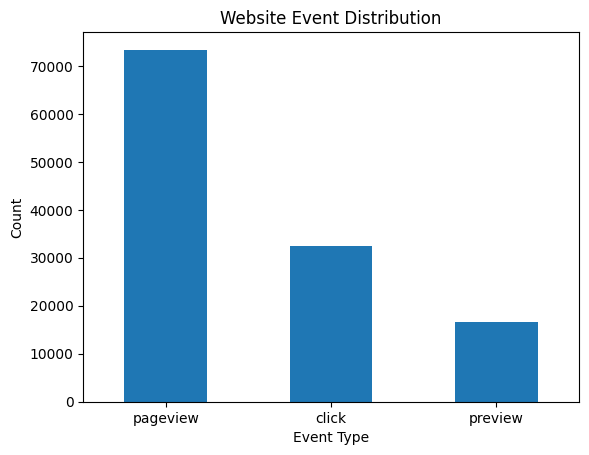

In [8]:
# Event distribution chart

event_counts = df["event"].value_counts()

event_counts.plot(kind="bar")

plt.title("Website Event Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

**Observation: Website Event Distribution**
* Pageviews recorded the highest activity with 73,360 events, indicating that
users frequently visit website pages.
* Click events accounted for 32,499 interactions, showing that a portion of visitors actively engage with content.
* Preview events were the lowest at 16,708, suggesting fewer users proceed deeper into content interaction.
* There is a noticeable drop from pageviews to clicks, indicating a potential conversion gap.
* User engagement decreases as users move through the interaction journey.

**Business Insight:**

The website attracts strong initial traffic, but user progression through the engagement funnel decreases. Improving call-to-action visibility, page design, and content relevance could help convert more visitors into active users.

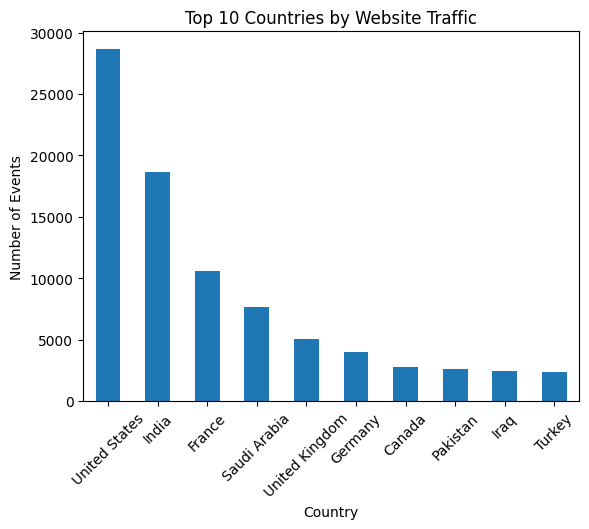

In [9]:
# Top 10 countries by traffic

top_countries = df["country"].value_counts().head(10)

top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Website Traffic")
plt.xlabel("Country")
plt.ylabel("Number of Events")

plt.xticks(rotation=45)

plt.show()

**Observation: Top Countries by Website Traffic**
* The United States generated the highest website traffic with approximately 29,000+ events, making it the strongest traffic source.
* India recorded the second-highest traffic with around 19,000 events, showing significant user engagement.
* France and Saudi Arabia contributed moderate traffic levels.
* Remaining countries such as United Kingdom, Germany, Canada, Pakistan, Iraq, and Turkey generated comparatively lower traffic.
* Website traffic distribution is uneven across countries, with a few regions contributing most of the activity.

**Business Insight:**

The website has strong market reach in the United States and India. Alfido Tech can increase growth by strengthening campaigns in high-performing regions while developing targeted marketing strategies in lower-performing countries.

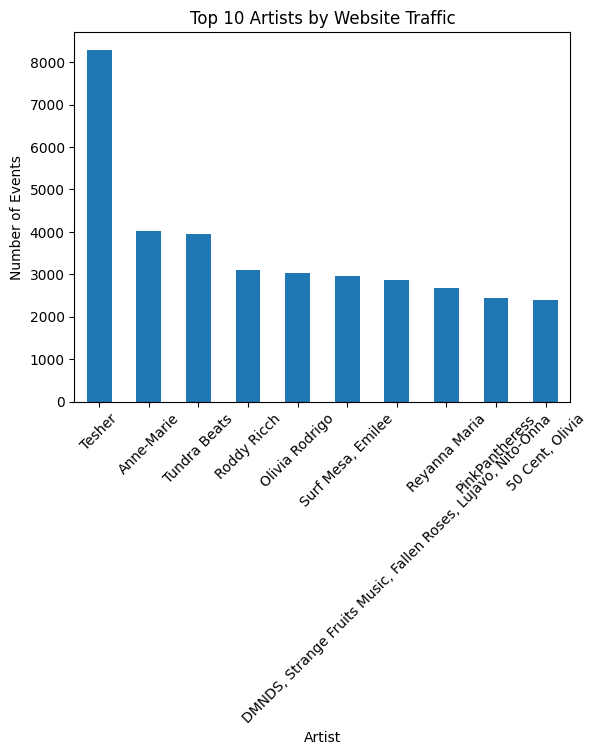

In [10]:
# Top 10 artists by traffic

top_artists = df["artist"].value_counts().head(10)

top_artists.plot(kind="bar")

plt.title("Top 10 Artists by Website Traffic")
plt.xlabel("Artist")
plt.ylabel("Number of Events")

plt.xticks(rotation=45)

plt.show()

**Observation: Top Artists by Website Traffic**
* Tesher generated the highest website traffic with approximately 8,000+ events, significantly outperforming other artists.
* Anne-Marie and Tundra Beats showed strong engagement and ranked among the top-performing content creators.
* Traffic gradually declines after the top few artists, indicating that user attention is concentrated on limited content.
* The gap between the top performer and lower-ranked artists suggests unequal content engagement.
* A small number of artists contribute a large proportion of user interactions.

**Business Insight:**

Popular content drives a major portion of website engagement. Alfido Tech can improve user retention by promoting high-performing content, recommending related content, and improving visibility for lower-performing content.

**Actionable Recommendations for Alfido Tech**

1. Improve click-through conversion

A large gap exists between pageviews and click events. Improve call-to-action buttons, page layouts, and content placement to encourage users to interact more frequently.

2. Focus on high-traffic regions

The United States and India generated the highest website activity. Increase targeted campaigns and marketing investments in these regions to maximize returns.

3. Promote related content

A small number of artists generate most traffic. Recommend similar content to users to increase engagement across less popular content.

4. Optimize lower-performing markets

Countries with lower traffic should receive localized promotions and region-specific campaigns to improve user acquisition.

5. Strengthen user retention

Introduce personalized recommendations, notifications, and engaging content strategies to encourage repeat visits and improve long-term engagement.

**Executive Summary**

This analysis examined website traffic data to understand user activity, engagement patterns, and content performance. Data cleaning involved handling missing values and removing duplicate records to improve analysis quality.

The dataset contained 122,567 valid records after cleaning and 3,839 unique users/sessions. Event analysis showed that pageviews represented the highest activity, followed by clicks and previews, indicating decreasing engagement through the interaction funnel.

Traffic distribution analysis revealed that the United States and India were the strongest traffic sources. Content analysis showed that a limited number of artists generated most user interactions, with Tesher emerging as the highest-performing artist.

Overall, the analysis indicates strong traffic generation but opportunities exist to improve engagement and conversion rates through better content recommendations, stronger user retention strategies, and targeted regional optimization.